# Titanic Survival Predictor

## End-to-end machine learning workflow

This notebook predicts whether a Titanic passenger survived using the Kaggle **Titanic: Machine Learning from Disaster** training dataset. It documents the complete workflow: exploration, preprocessing, feature engineering, Logistic Regression, evaluation, scaling, cross-validation, and hyperparameter tuning.

**Dataset:** `train.csv` (891 passengers; target: `Survived`)
> Put `train.csv` either next to this notebook or in a `data/` folder before running it.


## Workflow


Load data → Explore → Clean → Engineer features → Encode → Split → Scale → Train → Evaluate → Cross-validate → Tune


Key assumptions

- `Survived` is the target: `0` means did not survive and `1` means survived.
- `Age` missing values are filled with the training-data mean.
- `Embarked` missing values are filled with its most frequent value.
- `Cabin` is dropped in this baseline because most values are missing.
- `PassengerId`, `Name`, and `Ticket` are excluded from this first model; richer feature engineering can revisit `Name` and `Ticket` later.


## 1. Imports

In [3]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Dataset

The cell below looks for `train.csv` in common project locations. This keeps the notebook portable when moved into a GitHub repository.

In [5]:
data_paths = [
    Path("train.csv"),
    Path("data/train.csv"),
    Path("../data/train.csv"),
]

data_path = next((path for path in data_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find train.csv. Place it beside this notebook or in data/train.csv."
    )

raw_df = pd.read_csv(data_path)
print(f"Loaded {data_path} with shape: {raw_df.shape}")
raw_df.head()

Loaded train.csv with shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Exploratory Data Analysis (EDA)

+The purpose of EDA is to identify patterns that may help predict survival and to identify data-quality issues before modeling.

### 3.1 Dataset overview

In [6]:
display(raw_df.info())
display(raw_df.describe(include="all").T)
raw_df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

### 3.2 Target distribution

The target is `Survived`. We inspect both counts and percentages because percentages make comparisons easier.

,count,percentage
Survived,,
0,549,61.62
1,342,38.38


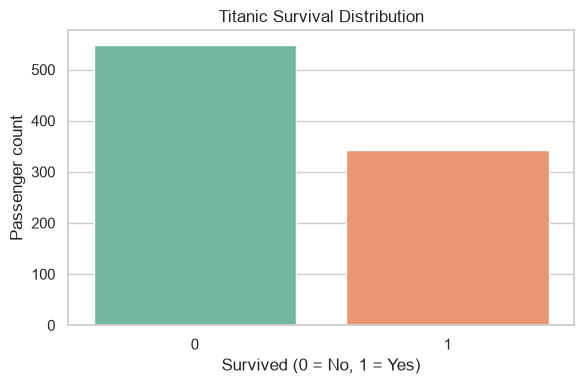

In [7]:
survival_counts = raw_df["Survived"].value_counts().sort_index()
survival_rate = (raw_df["Survived"].value_counts(normalize=True).sort_index() * 100).round(2)

display(pd.DataFrame({"count": survival_counts, "percentage": survival_rate}))

plt.figure(figsize=(6, 4))
sns.countplot(data=raw_df, x="Survived", hue="Survived", legend=False, palette="Set2")
plt.title("Titanic Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Passenger count")
plt.tight_layout()
plt.show()

### 3.3 Survival by sex and passenger class

These features showed clear relationships with survival during exploration.

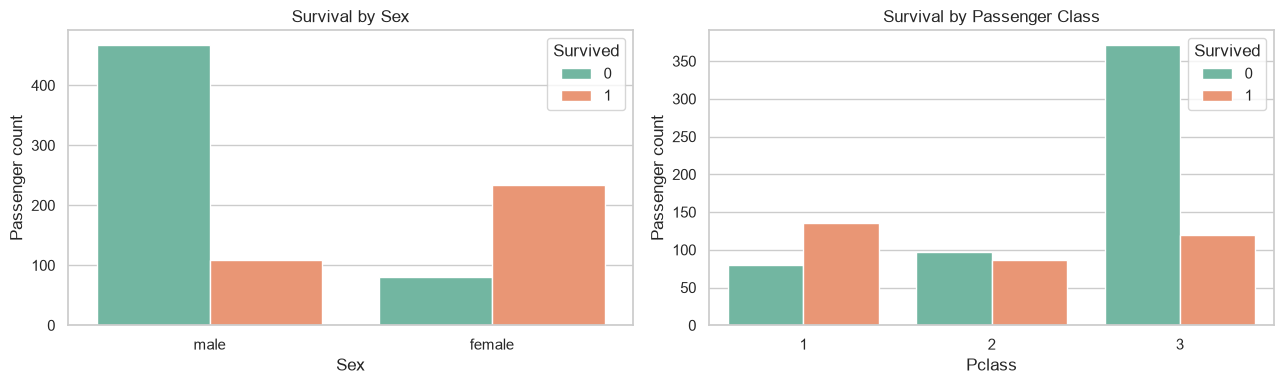

Sex
female    74.20
male      18.89
Name: survival_rate_pct, dtype: float64

Pclass
1    62.96
2    47.28
3    24.24
Name: survival_rate_pct, dtype: float64

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.countplot(data=raw_df, x="Sex", hue="Survived", ax=axes[0], palette="Set2")
axes[0].set_title("Survival by Sex")
axes[0].set_ylabel("Passenger count")

sns.countplot(data=raw_df, x="Pclass", hue="Survived", ax=axes[1], palette="Set2")
axes[1].set_title("Survival by Passenger Class")
axes[1].set_ylabel("Passenger count")

plt.tight_layout()
plt.show()

display((raw_df.groupby("Sex")["Survived"].mean() * 100).round(2).rename("survival_rate_pct"))
display((raw_df.groupby("Pclass")["Survived"].mean() * 100).round(2).rename("survival_rate_pct"))

### 3.4 Age and fare

Histograms and box plots help compare numerical features across survival groups.

/var/folders/p1/nx6ldf7x7jj60r8ytlfzqsr00000gn/T/ipykernel_20990/2974817444.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_df, x="Survived", y="Fare", ax=axes[1], palette="Set2")


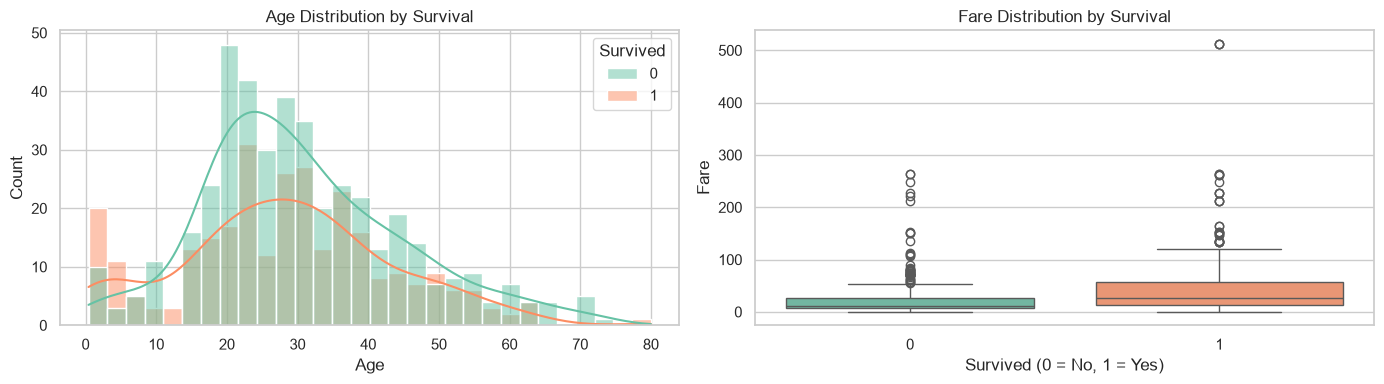

Survived
0    22.12
1    48.40
Name: average_fare, dtype: float64

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=raw_df, x="Age", hue="Survived", bins=30, kde=True, ax=axes[0], palette="Set2")
axes[0].set_title("Age Distribution by Survival")

sns.boxplot(data=raw_df, x="Survived", y="Fare", ax=axes[1], palette="Set2")
axes[1].set_title("Fare Distribution by Survival")
axes[1].set_xlabel("Survived (0 = No, 1 = Yes)")

plt.tight_layout()
plt.show()

display(raw_df.groupby("Survived")["Fare"].mean().round(2).rename("average_fare"))

### 3.5 Initial EDA observations

- The dataset contains a mix of numerical and categorical features.
- `Age`, `Cabin`, and `Embarked` have missing values; `Cabin` is mostly missing.
- Female passengers have a higher survival rate than male passengers.
- First-class passengers have a higher survival rate than lower-class passengers.
- Survivors generally paid higher fares.
- These observations are associations, not proof of causation.


## 4. Data Cleaning

Start from a fresh copy so that preprocessing is reproducible and does not modify the raw dataset.

In [10]:
df = raw_df.copy()

# Fill numerical missing values with the mean.
df["Age"] = df["Age"].fillna(df["Age"].mean())

# Fill categorical missing values with the most frequent category.
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Cabin is mostly missing, so this baseline model does not use it.
df.drop(columns=["Cabin"], inplace=True)

# Verify that missing values have been handled.
df.isnull().sum().sort_values(ascending=False)

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## 5. Feature Engineering

`SibSp` counts siblings/spouses and `Parch` counts parents/children. We combine them into `FamilySize`, including the passenger themself.

FamilySize
1     30.35
2     55.28
3     57.84
4     72.41
5     20.00
6     13.64
7     33.33
8      0.00
11     0.00
Name: survival_rate_pct, dtype: float64

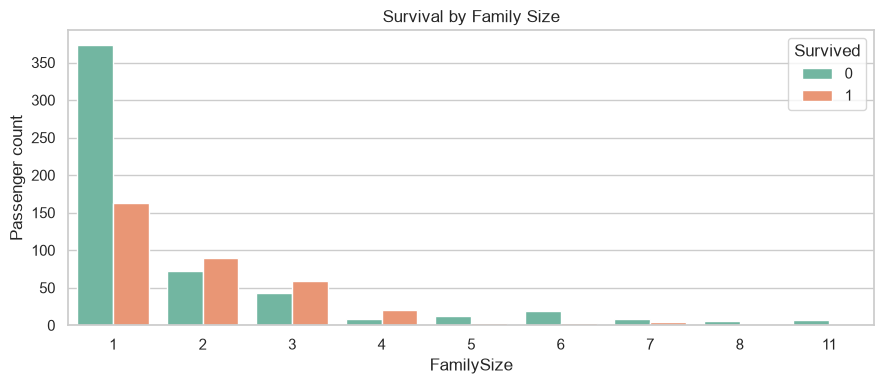

In [11]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

family_survival = (df.groupby("FamilySize")["Survived"].mean() * 100).round(2)
display(family_survival.rename("survival_rate_pct"))

plt.figure(figsize=(9, 4))
sns.countplot(data=df, x="FamilySize", hue="Survived", palette="Set2")
plt.title("Survival by Family Size")
plt.ylabel("Passenger count")
plt.tight_layout()
plt.show()

## 6. Encoding and Feature Selection

Machine-learning models require numeric input. The baseline drops identifier-like columns and encodes the remaining categorical variables.

In [12]:
# Identifier-like columns are excluded from the first baseline model.
df.drop(columns=["PassengerId", "Name", "Ticket"], inplace=True)

# Binary encoding: male = 0, female = 1.
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode the unordered embarkation port categories.
df = pd.get_dummies(
    df,
    columns=["Embarked"],
    drop_first=True,
    dtype=int,
)

print("Final modeling columns:")
print(df.columns.tolist())
df.head()

Final modeling columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Embarked_Q', 'Embarked_S']


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,2,0,1
1,1,1,1,38.0,1,0,71.2833,2,0,0
2,1,3,1,26.0,0,0,7.9250,1,0,1
3,1,1,1,35.0,1,0,53.1000,2,0,1
4,0,3,0,35.0,0,0,8.0500,1,0,1


## 7. Create Features and Target

`X` contains the passenger information available to the model. `y` is the answer the model must learn to predict.

In [13]:
X = df.drop(columns=["Survived"])
y = df["Survived"]

print(f"Feature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
display(X.head())
display(y.head())

Feature matrix shape: (891, 9)
Target shape: (891,)


,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,Embarked_Q,Embarked_S
0,3,0,22.0,1,0,7.2500,2,0,1
1,1,1,38.0,1,0,71.2833,2,0,0
2,3,1,26.0,0,0,7.9250,1,0,1
3,1,1,35.0,1,0,53.1000,2,0,1
4,3,0,35.0,0,0,8.0500,1,0,1


0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

## 8. Train-Test Split

We reserve 20% of the data as an unseen final test set. `random_state=42` makes the split reproducible.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (712, 9)
X_test:  (179, 9)
y_train: (712,)
y_test:  (179,)


## 9. Feature Scaling

`Age` and `Fare` have much larger ranges than binary features such as `Sex`. Standardization puts features on comparable scales. The scaler learns statistics only from `X_train`; applying `fit()` to test data would leak information from the test set.

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape: ", X_test_scaled.shape)

Scaled training shape: (712, 9)
Scaled testing shape:  (179, 9)


## 10. Logistic Regression

Logistic Regression is a classification model. During `fit()`, it learns coefficients that connect passenger features to the probability of survival.

In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted labels:", y_pred[:10])
print("First 10 survival probabilities:", y_prob[:10].round(3))

First 10 predicted labels: [0 0 0 1 1 1 1 0 1 1]
First 10 survival probabilities: [0.103 0.219 0.131 0.894 0.756 0.937 0.688 0.088 0.772 0.927]


## 11. Model Evaluation

Accuracy measures the fraction of correct predictions. The confusion matrix and classification report show the types of mistakes the model makes.

Test accuracy: 81.01%


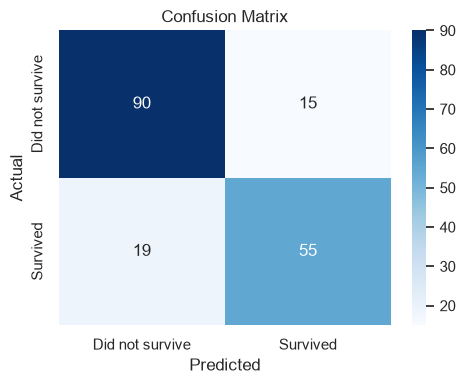

                 precision    recall  f1-score   support

Did not survive       0.83      0.86      0.84       105
       Survived       0.79      0.74      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



In [17]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.2%}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did not survive", "Survived"],
    yticklabels=["Did not survive", "Survived"],
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Did not survive", "Survived"]))

### 11.1 Coefficient interpretation

Positive coefficients push the prediction toward survival (`1`); negative coefficients push it toward non-survival (`0`). Coefficient magnitudes should be compared carefully, especially before scaling.

In [18]:
coefficients = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_[0],
}).sort_values("coefficient", ascending=False)

print(f"Intercept: {model.intercept_[0]:.3f}")
coefficients

Intercept: -0.676


,feature,coefficient
1,Sex,1.277119
5,Fare,0.125483
4,Parch,-0.018324
7,Embarked_Q,-0.039863
6,FamilySize,-0.171894
8,Embarked_S,-0.192035
3,SibSp,-0.233517
2,Age,-0.406044
0,Pclass,-0.787703


## 12. Cross Validation

The held-out test set remains untouched for final evaluation. We use 5-fold cross-validation only on the training data to estimate whether performance is consistent. A `Pipeline` is important here: it fits the scaler separately inside each fold, preventing data leakage.

In [19]:
cv_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000)),
])

cv_scores = cross_val_score(
    cv_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
)

print("Fold scores:", cv_scores.round(4))
print(f"Mean CV accuracy: {cv_scores.mean():.2%}")
print(f"CV standard deviation: {cv_scores.std():.2%}")

Fold scores: [0.8252 0.8042 0.7887 0.7394 0.7958]
Mean CV accuracy: 79.07%
CV standard deviation: 2.84%


## 13. GridSearchCV — Hyperparameter Tuning

This section tests several values of Logistic Regression's `C` hyperparameter using 5-fold cross-validation. It is deliberately kept small and readable; add more parameters only after establishing a baseline.

In [20]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=cv_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV accuracy: {grid_search.best_score_:.2%}")

Best parameters: {'model__C': 0.01}
Best CV accuracy: 80.05%


## 14. Final Test Evaluation

- After selecting hyperparameters with cross-validation, evaluate the best pipeline exactly once on the untouched test set.

In [21]:
best_model = grid_search.best_estimator_
final_predictions = best_model.predict(X_test)
final_accuracy = accuracy_score(y_test, final_predictions)

print(f"Final held-out test accuracy: {final_accuracy:.2%}")
print(classification_report(y_test, final_predictions, target_names=["Did not survive", "Survived"]))

Final held-out test accuracy: 79.33%
                 precision    recall  f1-score   support

Did not survive       0.79      0.88      0.83       105
       Survived       0.79      0.68      0.73        74

       accuracy                           0.79       179
      macro avg       0.79      0.78      0.78       179
   weighted avg       0.79      0.79      0.79       179



## 15. Conclusion and Next Steps

### What this notebook demonstrates

- A reproducible workflow from raw CSV data to evaluated classifier.
- Exploratory analysis to guide modeling decisions.
- Missing-value handling, feature engineering, and categorical encoding.
- Logistic Regression with scaling, test-set evaluation, cross-validation, and hyperparameter tuning.

### Suggested next improvements

1. Compare this baseline with decision trees and random forests.
2. Extract passenger titles from `Name` and deck letters from `Cabin`.
3. Use `ColumnTransformer` to keep all preprocessing inside one production pipeline.
4. Save the final model with `joblib` and build a web interface for new passenger predictions.
5. Add unit tests and a deployment workflow for the future web application.


*This notebook is part of the Titanic Survival Predictor portfolio project.*
